In [1]:
import sys
import re
import petab
import synapseclient
import pysb
import json

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import urllib.parse
import urllib.request

from collections import namedtuple
from pathlib import Path

from mEncoder.generate_data import generate_synthetic_data
from mEncoder import (
    load_pathway, data_dir, pretrain_dir,  PER_SAMPLE_OUTFILE_TEMP
)

SAMPLES = {
    'dream_cytof': [
        'c184A1', 'cBT20', 'cBT474', 'cBT549', 'cCAL148', 'cCAL851',
        'cCAL51', 'cDU4475', 'cEFM192A', 'cEVSAT', 'cHBL100', 'cHCC1187',
        'cHCC1395', 'cHCC1419', 'cHCC1500', 'cHCC1569', 'cHCC1599',
        'cHCC1937', 'cHCC1954', 'cHCC2157', 'cHCC2185', 'cHCC3153',
        'cHCC38', 'cHCC70', 'cHDQP1', 'cJIMT1', 'cMCF10A', 'cMCF10F',
        'cMCF7', 'cMDAMB134VI', 'cMDAMB157', 'cMDAMB175VII', 'cMDAMB361',
        'cMDAMB415', 'cMDAMB453', 'cMDAkb2', 'cMFM223', 'cMPE600', 'cMX1',
        'cOCUBM', 'cT47D', 'cUACC812', 'cUACC893', 'cZR7530'
    ],
    'synthetic': [f'sample_{isample}' for isample in range(20)],
}

Wildcards = namedtuple('Wildcards', ['data', 'samples'])


def training_samples(wildcards):
    samples = SAMPLES[wildcards.data]
    split, n_splits = wildcards.samples.split('_')
    split = int(split)
    n_splits = int(n_splits)
    n_samples = len(samples)
    return samples[:int(np.round(n_samples/n_splits*split))] + \
        samples[int(np.round(n_samples/n_splits*(split+1))):]


def test_samples(wildcards):
    samples = SAMPLES[wildcards.data]
    split, n_splits = wildcards.samples.split('_')
    split = int(split)
    n_splits = int(n_splits)
    n_samples = len(samples)
    return samples[int(np.round(n_samples/n_splits*split)):
                   int(np.round(n_samples/n_splits*(split+1))):]


def pretraining_samples_fun(wildcards):
    return [
        pretrain_dir / '{model}' / '{data}' /
        PER_SAMPLE_OUTFILE_TEMP.format(sample=sample)
        for sample in training_samples(wildcards)
    ]


def observable_id_to_model_expr(obs_id: str,
                                dataset: str,
                                model: pysb.Model) -> str:
    """
    Maps site definitions from data to model observables

    :param obs_id:
        identifier of the phosphosite in the data table

    :param dataset:
        identifier of the dataset. Used to setup parse observable information

    :param model:
        model to which the observables are mapped

    :return:
        the name of the corresponding observable in the model
    """
    obs_id = obs_id.replace('-', '_').upper()
    if dataset == 'cytof':
        palias = {
            r'^P\.STAT5': 'STAT5A_Y694',
            r'^P\.MEK': 'pMEK_S221',
            r'^P\.S6K$': 'RPS6KB1_S412',
            r'^P\.STAT1': 'STAT1_Y727',
            r'^P\.AKT\.SER473\.': 'pAKT_S473',
            r'^P\.ERK': 'pERK_Y204',
            r'^P\.HER2': 'ERBB2_Y1248',
            r'^P\.GSK3B': 'GSK3B_S9',
            r'^P\.PDPK1': 'PDPK1_S241',
            r'^P\.P90RSK': 'RPS6KA1_S380',
            r'^P\.STAT3': 'STAT3_Y705',
            r'^P\.S6$': 'RPS6_S235_S236',
            r'^P\.AKT\.THR308\.': 'pAKT_T308',
            r'^P\.4EBP1': 'EIF4EBP1_T37_T46',
            r'^P\.SRC': 'SRC_Y419',
            r'^P\.p.PLCG2': 'PLCG2_Y759',
            r'^P\.BTK': 'BTK_Y551',
            r'^P\.CREB': 'CREB1_S133',
        }
    else:
        raise ValueError('Dataset not supported!')

    for pname, prep in palias.items():
        obs_id = re.sub(pname, prep, obs_id)

    if model.observables.get(obs_id, None):
        return obs_id

    site_pattern = r'_([S|Y|T][0-9]+)'

    monomer = re.sub(site_pattern, '', obs_id)
    sites = sorted(list(re.findall(site_pattern, obs_id)))

    name = f'p{monomer}_{"_".join(sites)}' if sites else f't{obs_id}'

    if model.observables.get(name, None):
        return name

    if model.monomers.get(monomer, None) and name.startswith('p'):
        print(f'could not map {obs_id} to {monomer}!')

    return ''


def convert_time_to_minutes(time_str):
    if not isinstance(time_str, str):
        return float(time_str)
    if time_str.endswith('min'):
        return float(time_str[:-4])
    if time_str.endswith('hr'):
        return float(time_str[:-3])*60

In [2]:
MODEL = 'EGFR_MAPK'
DATA = 'dream_cytof'
model = load_pathway('pw_' + MODEL)

In [3]:
syn = synapseclient.Synapse()
syn.login()
files = [
    'syn20613594',  # 184A1
    'syn20613595',  # BT20
    'syn20613596',  # BT474
    'syn20613597',  # BT549
    'syn20613598',  # CAL148
    'syn20613599',  # CAL51
    'syn20613600',  # CAL851
    'syn20613601',  # DU4475
    'syn20613660',  # EFM192A
    'syn20613665',  # EVSAT
    'syn20613668',  # HBL100
    'syn20613674',  # HCC1187
    'syn20613687',  # HCC1395
    'syn20613696',  # HCC1419
    'syn20613702',  # HCC1500
    'syn20613708',  # HCC1569
    'syn20613710',  # HCC1599
    'syn20613719',  # HCC1937
    'syn20613739',  # HCC1954
    'syn20613793',  # HCC2157
    'syn20613802',  # HCC2185
    'syn20613814',  # HCC3153
    'syn20613821',  # HCC38
    'syn20613832',  # HCC70
    'syn20613849',  # HDQP1
    'syn20613865',  # JIMT1
    'syn20613880',  # MCF10A
    'syn20613911',  # MCF10F
    'syn20613920',  # MCF7
    'syn20613935',  # MDAMB134VI
    'syn20613939',  # MDAMB157
    'syn20613943',  # MDAMB175VII
    'syn20613962',  # MDAMB361
    'syn20613975',  # MDAMB415
    'syn20613988',  # MDAMB453
    'syn20613930',  # MDAkb2
    'syn20613995',  # MFM223
    'syn20614008',  # MPE600
    'syn20614033',  # MX1
    'syn20614045',  # OCUBM
    'syn20614052',  # T47D
    'syn20614063',  # UACC812
    'syn20614074',  # UACC893
    'syn20614085',  # ZR7530
]
mean_data = []
std_data = []
group_ids = ['treatment', 'cell_line', 'time', 'fileID']
corr_data = []
for file in files:
    df = pd.read_csv(syn.get(file).path)
    for ids, data in df.groupby(group_ids):
        if f'c{ids[1]}' not in SAMPLES[DATA]:
            continue
        markers = [c for c in data.columns
                   if c not in group_ids + ['cellID']]
        m = data[markers].median()
        std = data[markers].std()
        for sdf in [m, std]:
            sdf['treatment'] = ids[0]
            sdf['cell_line'] = ids[1]
            sdf['time'] = ids[2]
            sdf['fileID'] = ids[3]


        plt.show()
        mean_data.append(m)
        std_data.append(std)
        if ids[2] == 0:
            corr_data.append(data[::100])

Welcome, Fabian Froehlich!



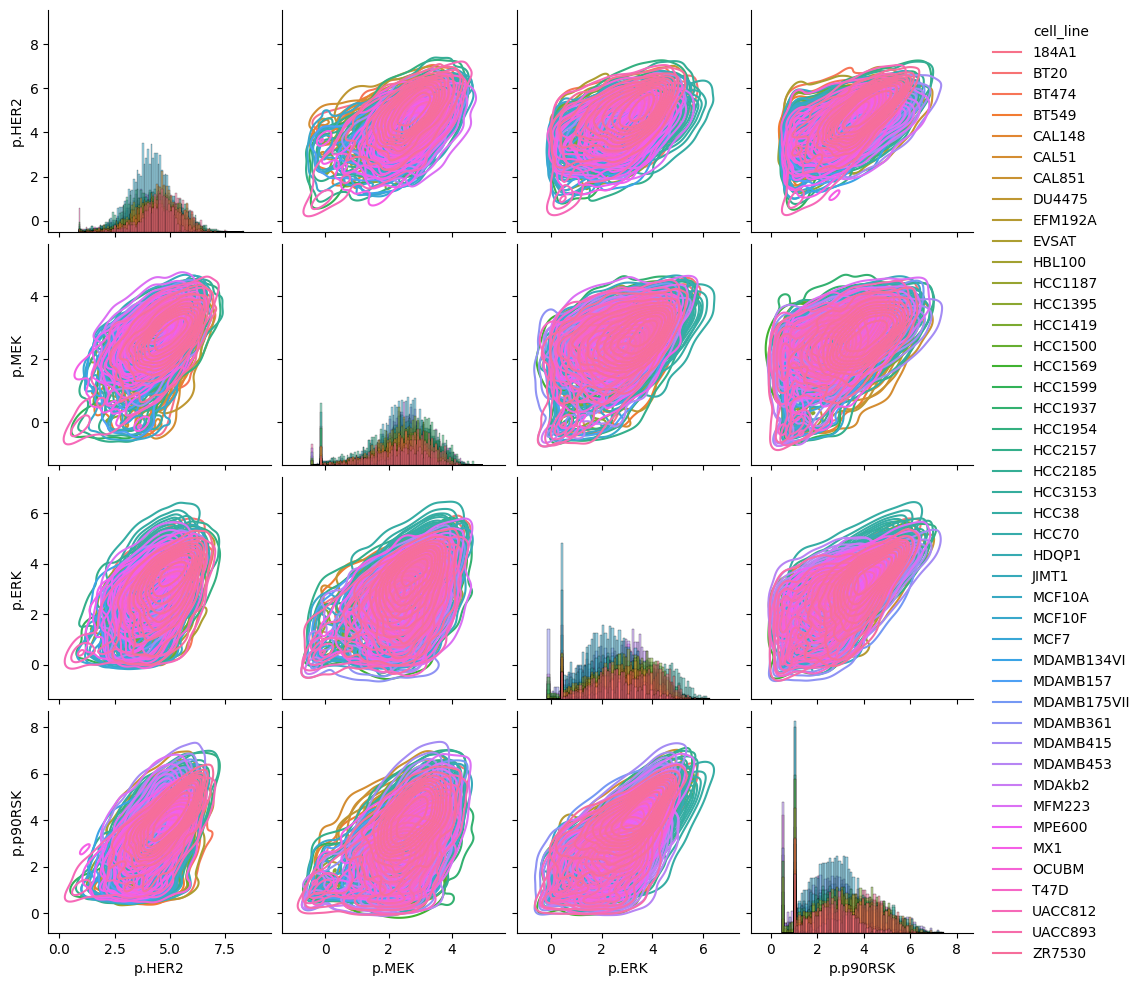

In [8]:
df_pp = pd.concat(corr_data)
sns.pairplot(
    data=df_pp.reset_index(),
    vars=['p.HER2', 'p.MEK', 'p.ERK', 'p.p90RSK'],
    diag_kind='hist',
    kind='kde',
    hue='cell_line',
)
plt.show()